# Jane Street Supervised Autoencoder MLP — Supervised by Design

**Docker image**: `ml4t-gpu`

**Chapter 14: Latent Factors**

This notebook implements the winning solution from the Jane Street Market
Prediction Kaggle competition (2020-2021) and explains why supervised
autoencoders sit *outside* the chapter's two-step factor-forecasting
framework alongside the SDF.

## Why no Stage 2 — supervised by design

PCA, IPCA, RP-PCA, and CAE all fit the framework as **Stage 1 (factor
model) → Stage 2 (factor-premium forecaster) → Stage 3 (asset mapper)**.
Their factor extraction is unsupervised (or only weakly supervised on
variance / pricing-error objectives), so a Stage 2 forecaster is required
to turn the factor history $F$ into $\hat\lambda_{t+1}$ before Stage 3
produces a per-asset signal.

The SAE is different. Its training objective is
$$\mathcal{L} = \mathrm{MSE}(\hat x, x) + \alpha\,\mathrm{BCE}\bigl(\hat p^{\text{aux}}, \mathbb{1}[r^{\text{fwd}}>0]\bigr) + \beta\,\mathrm{BCE}\bigl(\hat p^{\text{main}}, \mathbb{1}[r^{\text{fwd}}>0]\bigr)$$

where $\hat x$ is the reconstruction of the input characteristics, the
auxiliary head predicts the binarised direction of forward returns from
the encoded representation, and the main head produces the post-decoder
direction prediction used for the final AUC score. The encoder, the
auxiliary head, **and the main head** are all trained end-to-end on the
binarised forward-return targets. The bottleneck representation is shaped
by the supervised classification loss, not by an unsupervised factor
objective. So:

- The SAE's "factors" (the bottleneck activations) are **already conditioned
  on the prediction target**. There is no separate $F \to \hat\lambda$ step
  to perform — the network has already learned what the next-period return
  distribution looks like given the input features.
- The "asset mapper" (Stage 3 in the framework) is the main MLP head. It
  is fitted jointly with everything upstream.
- The closest framework analogue is **SDF + beta network** (notebook 07,
  §10): both fold the per-asset prediction into the architecture itself.
  SAE skips even the SDF's Stage-1-like pricing-kernel objective —
  reconstruction acts purely as regularisation, not as a structural
  factor model.

**Practical implication**: don't paste the Constant / AR(1) / EWMA
forecaster catalog from notebook 04/05/06 onto this model. The signal is
the network's main-head output, $\hat p^{\text{main}}_{t+1,i}$, the
predicted probability that $r^{\text{fwd}}_{t+1,i}>0$, evaluated against
the binarised direction label. This notebook reports per-horizon AUC on
that classification target.

## Attribution

> **1st Place Solution by Yirun Zhang (gogo827jz)** "Supervised Autoencoder
> with MLP", Jane Street Market Prediction (2020-2021).
> [Kaggle Notebook](https://www.kaggle.com/code/gogo827jz/jane-street-supervised-autoencoder-mlp)
> · [Competition Writeup](https://www.kaggle.com/competitions/jane-street-market-prediction/discussion/224348)

Original TensorFlow/Keras; this is an educational PyTorch port.

---

## Why Supervised Autoencoders? (The Key Insight)

**The Problem**: Financial features are noisy, redundant, and often have missing values.
Standard MLPs can overfit to noise, especially with 130+ features.

**The Solution - Multi-Task Learning**:

Instead of a single prediction task, train the model on THREE objectives simultaneously:

1. **Reconstruction** (unsupervised): Force the encoder to learn meaningful representations
   by requiring it to reconstruct the original 130 features from a 96-dim bottleneck.

2. **Auxiliary Prediction** (supervised): Make predictions directly from the bottleneck.
   This forces the compressed representation to be predictive, not just reconstructive.

3. **Main Prediction** (supervised): Full MLP using both original features AND bottleneck.
   Gets the best of both worlds: raw signal + denoised representation.

**Why This Works**:
- The reconstruction loss acts as **regularization** - the encoder must capture real structure
- The auxiliary head prevents the bottleneck from being a "dead end"
- Skip connections ensure gradient flow to all parts of the network
- Multi-task learning shares representations across objectives

---

## Architecture Overview

Figure `020_ad2d43f0.png` (rendered below) shows the SAE wiring diagram:
input → BatchNorm + Gaussian noise → encoder (Dense 96) → decoder (Dense 130,
reconstruction MSE) and auxiliary head (Dense 96 → 5, BCE) → concatenate with
the encoder bottleneck → main MLP head (896 / 448 / 448 / 256, BCE on the
primary target). The encoder feeds both the reconstruction path and the main
prediction head, so the bottleneck representation is shaped by all three
losses simultaneously.

---

## Key Hyperparameters (from the Jane Street 2020-21 reference implementation)

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Bottleneck dim | 96 | Compress 130 → 96 (mild compression) |
| MLP widths | [896, 448, 448, 256] | Wide first layer, then narrow |
| Dropout (input) | GaussianNoise(0.035) | Additive noise, not multiplicative |
| Dropout (layers) | 0.1 - 0.5 | Higher in middle layers |
| Activation | Swish | Smoother than ReLU, no dead neurons |
| Batch size | 4096 | Large batches for stable BatchNorm |

---

## Learning Objectives

- LO1: Understand multi-task learning and why it helps in finance
- LO2: Implement supervised autoencoders with skip connections
- LO3: Apply purged cross-validation for time series

**Prerequisites**: [`06_conditional_autoencoder`](06_conditional_autoencoder.ipynb) (CAE architecture);
familiarity with PyTorch training loops (Chapter 13).

**Book Reference**: Chapter 14, §14.7 (Implementation Workshop)

## 1. Setup and Imports

In [1]:
"""Supervised Autoencoder — Multi-task learning with reconstruction regularization."""

import warnings
from time import time

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

from data import load_us_equities
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Universe-Size Scaling

SAE training cost scales as $O(\text{N\_SPLITS} \cdot \text{N\_EPOCHS} \cdot
T_{\text{train}} \cdot \text{N\_STOCKS})$ — one full fit per CV fold. The
default 500-stock × 5-fold × 50-epoch run finishes in ~2 minutes on the local
3090 (under a minute per fold) thanks to the small parameter count. CPU-only
runs are ~10× slower. To smoke-test, drop `N_SPLITS` to 1 first; the per-fold
cost is the unit of feedback. Increasing `N_STOCKS` past ~1 000 starts to
pressure GPU memory at the default `BATCH_SIZE`.

In [2]:
# Production defaults (Papermill overrides for CI testing)
N_STOCKS = 500
N_EPOCHS = 50
BATCH_SIZE = 4096
N_SPLITS = 5
START_DATE = "1995-01-01"
END_DATE = "2018-12-31"
SEED = 42

In [3]:
set_global_seeds(SEED)
RANDOM_SEED = SEED
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

## 2. Data Loading

We use US Equities (NASDAQ Data Link, 3,199 stocks, 1962–2018) to create a
Jane Street-like dataset:
- Multiple features computed from price/volume data
- 5 response variables (forward returns at different horizons)
- Time-series structure with dates for purged CV

### Load and Filter Equity Data

Load US equities via the official loader and select the most liquid stocks
by average volume.

In [4]:
print("Loading US equities for Jane Street-style model...")
equities_raw = load_us_equities(start_date=START_DATE, end_date=END_DATE)
print(f"  US Equities: {equities_raw.shape}")

equities = equities_raw.sort(["symbol", "timestamp"])

top_stocks = (
    equities.group_by("symbol")
    .agg(pl.col("volume").mean().alias("avg_volume"))
    .sort("avg_volume", descending=True)
    .head(N_STOCKS)["symbol"]
    .to_list()
)
equities = equities.filter(pl.col("symbol").is_in(top_stocks))

Loading US equities for Jane Street-style model...


  US Equities: (13275631, 14)


### Compute Features and Forward Returns

Engineer Jane Street-like features: momentum, volatility, z-scores, volume ratios,
and price position. Forward returns at 5 horizons serve as multi-task targets.

In [5]:
equities = equities.with_columns(
    [
        pl.col("adj_close").pct_change().over("symbol").alias("ret_1d"),
        pl.col("adj_close").pct_change(5).over("symbol").alias("mom_5d"),
        pl.col("adj_close").pct_change(10).over("symbol").alias("mom_10d"),
        pl.col("adj_close").pct_change(20).over("symbol").alias("mom_20d"),
        pl.col("adj_close").pct_change(40).over("symbol").alias("mom_40d"),
        pl.col("adj_close").pct_change(60).over("symbol").alias("mom_60d"),
        pl.col("adj_close").pct_change().rolling_std(5).over("symbol").alias("vol_5d"),
        pl.col("adj_close").pct_change().rolling_std(10).over("symbol").alias("vol_10d"),
        pl.col("adj_close").pct_change().rolling_std(20).over("symbol").alias("vol_20d"),
        pl.col("adj_close").pct_change().rolling_std(60).over("symbol").alias("vol_60d"),
        (
            (pl.col("adj_close") - pl.col("adj_close").rolling_mean(10).over("symbol"))
            / pl.col("adj_close").rolling_std(10).over("symbol")
        ).alias("zscore_10d"),
        (
            (pl.col("adj_close") - pl.col("adj_close").rolling_mean(20).over("symbol"))
            / pl.col("adj_close").rolling_std(20).over("symbol")
        ).alias("zscore_20d"),
        (
            (pl.col("adj_close") - pl.col("adj_close").rolling_mean(60).over("symbol"))
            / pl.col("adj_close").rolling_std(60).over("symbol")
        ).alias("zscore_60d"),
        (pl.col("volume") / pl.col("volume").rolling_mean(10).over("symbol")).alias(
            "vol_ratio_10d"
        ),
        (pl.col("volume") / pl.col("volume").rolling_mean(20).over("symbol")).alias(
            "vol_ratio_20d"
        ),
        pl.col("adj_close").log().alias("log_price"),
        (pl.col("adj_close") / pl.col("adj_close").rolling_max(20).over("symbol")).alias(
            "price_to_high_20d"
        ),
        (pl.col("adj_close") / pl.col("adj_close").rolling_min(20).over("symbol")).alias(
            "price_to_low_20d"
        ),
        pl.col("adj_close").pct_change(1).shift(-1).over("symbol").alias("fwd_ret_1d"),
        pl.col("adj_close").pct_change(5).shift(-5).over("symbol").alias("fwd_ret_5d"),
        pl.col("adj_close").pct_change(10).shift(-10).over("symbol").alias("fwd_ret_10d"),
        pl.col("adj_close").pct_change(20).shift(-20).over("symbol").alias("fwd_ret_20d"),
        pl.col("adj_close").pct_change(40).shift(-40).over("symbol").alias("fwd_ret_40d"),
    ]
).drop_nulls()

### Define Feature and Target Columns

17 features (momentum, volatility, z-scores, volume ratios, price position) and
5 forward-return horizons as multi-task targets.

In [6]:
feature_cols = [
    "mom_5d",
    "mom_10d",
    "mom_20d",
    "mom_40d",
    "mom_60d",
    "vol_5d",
    "vol_10d",
    "vol_20d",
    "vol_60d",
    "zscore_10d",
    "zscore_20d",
    "zscore_60d",
    "vol_ratio_10d",
    "vol_ratio_20d",
    "log_price",
    "price_to_high_20d",
    "price_to_low_20d",
]
target_cols = ["fwd_ret_1d", "fwd_ret_5d", "fwd_ret_10d", "fwd_ret_20d", "fwd_ret_40d"]

### Build Arrays for Training

Convert to numpy arrays: features, binary labels (positive return = action),
response weights (absolute return magnitude), and date indices for purged CV.

In [7]:
features = equities.select(feature_cols).to_numpy().astype(np.float32)
responses = equities.select(target_cols).to_numpy().astype(np.float32)
labels = (responses > 0).astype(np.float32)
weights = np.abs(responses).mean(axis=1).astype(np.float32)

# Date indices for purged CV
unique_dates = equities["timestamp"].unique().sort().to_list()
date_to_idx = {d: i for i, d in enumerate(unique_dates)}
dates = np.array([date_to_idx[d] for d in equities["timestamp"].to_list()])

# Handle remaining NaN/Inf
features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
responses = np.nan_to_num(responses, nan=0.0, posinf=0.0, neginf=0.0)
labels = np.nan_to_num(labels, nan=0.0)
weights = np.nan_to_num(weights, nan=0.0)

data = {
    "features": features,
    "labels": labels,
    "responses": responses,
    "dates": dates,
    "weights": weights,
}
n_features = features.shape[1]
n_labels = labels.shape[1]

print(f"  Loaded {features.shape[0]:,} samples, {n_features} features")
print(f"  Date range: {len(unique_dates)} trading days, Stocks: {N_STOCKS}")

  Loaded 2,202,576 samples, 17 features
  Date range: 5750 trading days, Stocks: 500


## 3. Preprocessing

Missing-value handling is upstream: the feature engineering step calls
``drop_nulls()`` after computing rolling features, and any remaining NaN
or Inf values in the float arrays are replaced with zero via
``np.nan_to_num`` immediately after array construction. The Jane Street
reference pipeline added a global forward-fill over the flattened sample
order; we drop that step here because the sample order is
``(symbol, timestamp)`` after the Polars sort, so a flat ffill would leak
the last value of one symbol's history into the next symbol's earliest
row. The simplified pass-through below preserves the function-level
preprocessing boundary for future per-symbol logic without that hazard.

In [8]:
def preprocess_data(data: dict) -> dict:
    """Pass-through hook for preprocessing.

    Upstream feature construction already runs ``drop_nulls()`` and
    ``np.nan_to_num``, so there are no missing values to handle here. The
    function is retained as the extension point if per-symbol smoothing is
    added later.
    """
    return {
        "features": data["features"],
        "labels": data["labels"],
        "responses": data["responses"],
        "dates": data["dates"],
        "weights": data["weights"],
    }

In [9]:
data = preprocess_data(data)
print(f"After preprocessing - Missing: {np.isnan(data['features']).sum()}")

After preprocessing - Missing: 0


## 4. Model Architecture

### The Swish Activation

The Swish activation (also called SiLU) is defined as:

$$\text{Swish}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$$

> **Import shortcut**: These classes are also available as
> `from case_studies.config.sae.sae import SupervisedAutoencoder` for use outside
> this notebook. The inline definition below is shown for pedagogical exposition.

Better than ReLU because:
- Smooth, no "kink" at 0
- Non-monotonic: can decrease for negative inputs
- Self-gated: the sigmoid acts as a learned gate
- No dead neurons (ReLU can have 0 gradient for negative inputs)

### Block diagram

Encoder produces a 96-dim bottleneck $z$. Three branches read $z$:
decoder reconstructs the input (regularises $z$ via MSE), the auxiliary
head predicts the binarised direction of the five forward-return horizons
(forces $z$ to be predictive, BCE loss), and the main MLP reads $[x, z]$
via a skip connection to produce the per-horizon directional probabilities
(BCE loss). Total loss sums reconstruction MSE + auxiliary BCE + main BCE.

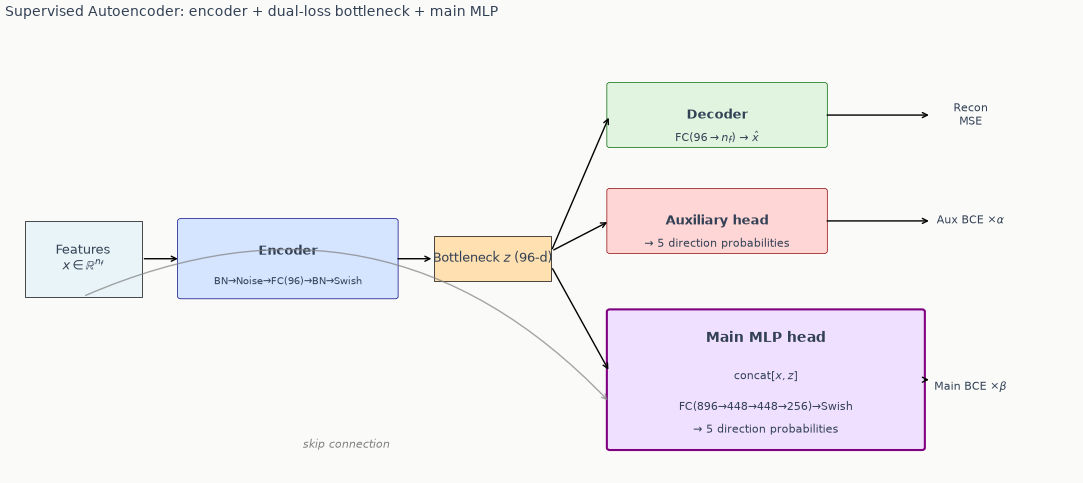

In [10]:
from matplotlib.patches import FancyBboxPatch, Rectangle  # noqa: E402

fig, ax = plt.subplots(figsize=(11, 5.0))
ax.set_xlim(0, 110)
ax.set_ylim(0, 60)
ax.axis("off")

ax.add_patch(Rectangle((2, 24), 12, 10, facecolor="#E8F4F8", edgecolor="black"))
ax.text(8, 29, "Features\n$x \\in \\mathbb{R}^{n_f}$", ha="center", va="center", fontsize=9)

ax.add_patch(
    FancyBboxPatch(
        (18, 24),
        22,
        10,
        boxstyle="round,pad=0.3",
        facecolor="#D6E5FF",
        edgecolor="navy",
    )
)
ax.text(29, 30, "Encoder", ha="center", va="center", fontweight="bold", fontsize=9)
ax.text(29, 26, "BN→Noise→FC(96)→BN→Swish", ha="center", va="center", fontsize=7.5)

ax.add_patch(Rectangle((44, 26), 12, 6, facecolor="#FFE0B0", edgecolor="black"))
ax.text(50, 29, r"Bottleneck $z$ (96-d)", ha="center", va="center", fontsize=9)

ax.add_patch(
    FancyBboxPatch(
        (62, 44),
        22,
        8,
        boxstyle="round,pad=0.3",
        facecolor="#E0F4E0",
        edgecolor="darkgreen",
    )
)
ax.text(73, 48, "Decoder", ha="center", va="center", fontweight="bold", fontsize=9)
ax.text(73, 45, r"FC$(96 \to n_f)$ → $\hat{x}$", ha="center", va="center", fontsize=8)

ax.add_patch(
    FancyBboxPatch(
        (62, 30),
        22,
        8,
        boxstyle="round,pad=0.3",
        facecolor="#FFD6D6",
        edgecolor="darkred",
    )
)
ax.text(73, 34, "Auxiliary head", ha="center", va="center", fontweight="bold", fontsize=9)
ax.text(73, 31, "→ 5 direction probabilities", ha="center", va="center", fontsize=8)

ax.add_patch(
    FancyBboxPatch(
        (62, 4),
        32,
        18,
        boxstyle="round,pad=0.3",
        facecolor="#F0E0FF",
        edgecolor="purple",
        lw=1.5,
    )
)
ax.text(78, 18, "Main MLP head", ha="center", fontweight="bold", fontsize=10)
ax.text(78, 13, r"concat$[x, z]$", ha="center", fontsize=8)
ax.text(78, 9, "FC(896→448→448→256)→Swish", ha="center", fontsize=8)
ax.text(78, 6, "→ 5 direction probabilities", ha="center", fontsize=8)

ax.text(99, 48, "Recon\nMSE", ha="center", va="center", fontsize=8)
ax.text(99, 34, r"Aux BCE $\times \alpha$", ha="center", va="center", fontsize=8)
ax.text(99, 12, r"Main BCE $\times \beta$", ha="center", va="center", fontsize=8)

arrow = dict(arrowstyle="->", color="black", lw=1)
ax.annotate("", xy=(18, 29), xytext=(14, 29), arrowprops=arrow)
ax.annotate("", xy=(44, 29), xytext=(40, 29), arrowprops=arrow)
ax.annotate("", xy=(62, 48), xytext=(56, 30), arrowprops=arrow)
ax.annotate("", xy=(62, 34), xytext=(56, 30), arrowprops=arrow)
ax.annotate("", xy=(62, 14), xytext=(56, 28), arrowprops=arrow)
ax.annotate("", xy=(95, 48), xytext=(84, 48), arrowprops=arrow)
ax.annotate("", xy=(95, 34), xytext=(84, 34), arrowprops=arrow)
ax.annotate("", xy=(95, 13), xytext=(94, 13), arrowprops=arrow)

ax.annotate(
    "",
    xy=(62, 10),
    xytext=(8, 24),
    arrowprops=dict(
        arrowstyle="->",
        color="gray",
        lw=1,
        alpha=0.7,
        connectionstyle="arc3,rad=-0.35",
    ),
)
ax.text(35, 4, "skip connection", ha="center", fontsize=8, color="gray", style="italic")

ax.set_title("Supervised Autoencoder: encoder + dual-loss bottleneck + main MLP")
fig.tight_layout()
fig.show()

In [11]:
class Swish(nn.Module):
    """
    Swish activation: x * sigmoid(x)

    Also known as SiLU (Sigmoid Linear Unit). PyTorch provides nn.SiLU()
    natively since v1.7; we implement it explicitly here for pedagogical
    clarity — understanding the gating mechanism is valuable.
    """

    def forward(self, x):
        return x * torch.sigmoid(x)

In [12]:
class GaussianNoise(nn.Module):
    """
    Add Gaussian noise during training (dropout alternative).

    Unlike dropout (multiplicative noise), this is additive noise.
    Better for continuous features where we want to add uncertainty,
    not zero out entire features.

    Args:
        std: Standard deviation of noise to add
    """

    def __init__(self, std: float = 0.1):
        super().__init__()
        self.std = std

    def forward(self, x):
        if self.training:
            noise = torch.randn_like(x) * self.std
            return x + noise
        return x

### Supervised Autoencoder Architecture

The three-headed network: encoder $\to$ bottleneck $\to$ (decoder, auxiliary head, main MLP).
Skip connections concatenate original features with the bottleneck for the main head.

**`__init__` builds four network sections**:

1. **Encoder** -- `BatchNorm` $\to$ `GaussianNoise` $\to$ `Linear(n_features, 96)`
   $\to$ `BN` $\to$ `Swish`. Compresses 17 input features to a 96-dim bottleneck.
2. **Decoder** -- `Dropout` $\to$ `Linear(96, n_features)`. Reconstructs the
   original features from the bottleneck (MSE loss acts as regularization).
3. **Auxiliary head** -- `Linear(n_features, 96)` $\to$ `BN` $\to$ `Swish` $\to$
   `Dropout` $\to$ `Linear(96, 5)` $\to$ `Sigmoid`. Predicts from decoder output,
   forcing the bottleneck to be predictive, not just reconstructive.
4. **Main MLP head** -- Skip connection concatenates `[x_norm, encoded]`, then
   passes through `BN` $\to$ `Dropout` $\to$ 4-layer MLP `[896, 448, 448, 256]`
   $\to$ `Linear(256, 5)` $\to$ `Sigmoid`.

**`forward`** runs all four sections and returns `(decoded, aux_pred, main_pred)`.
**`predict`** is the inference shortcut returning only `main_pred`.

In [13]:
class SupervisedAutoencoder(nn.Module):
    """Jane Street Supervised Autoencoder MLP -- three-headed multi-task architecture."""

    def __init__(
        self,
        n_features: int,
        n_labels: int = 5,
        hidden_units: list = None,
        dropout_rates: list = None,
        noise_std: float = 0.035,
    ):
        super().__init__()
        if hidden_units is None:
            hidden_units = [96, 96, 896, 448, 448, 256]
        if dropout_rates is None:
            dropout_rates = [0.035, 0.038, 0.424, 0.104, 0.492, 0.320, 0.272, 0.438]

        self.n_features = n_features
        self.n_labels = n_labels

        # --- Encoder: compress input to bottleneck ---
        self.input_bn = nn.BatchNorm1d(n_features)
        self.input_noise = GaussianNoise(noise_std)
        self.encoder = nn.Sequential(
            nn.Linear(n_features, hidden_units[0]),
            nn.BatchNorm1d(hidden_units[0]),
            Swish(),
        )

        # --- Decoder: reconstruct input from bottleneck ---
        self.decoder_dropout = nn.Dropout(dropout_rates[1])
        self.decoder = nn.Linear(hidden_units[0], n_features)

        # --- Auxiliary head: predict from decoder output ---
        self.aux_head = nn.Sequential(
            nn.Linear(n_features, hidden_units[1]),
            nn.BatchNorm1d(hidden_units[1]),
            Swish(),
            nn.Dropout(dropout_rates[2]),
            nn.Linear(hidden_units[1], n_labels),
            nn.Sigmoid(),
        )

        # --- Main MLP head: skip connection + deep MLP ---
        concat_dim = n_features + hidden_units[0]
        self.main_bn = nn.BatchNorm1d(concat_dim)
        self.main_dropout_input = nn.Dropout(dropout_rates[3])

        mlp_layers = []
        in_dim = concat_dim
        for i, out_dim in enumerate(hidden_units[2:]):
            mlp_layers.extend(
                [
                    nn.Linear(in_dim, out_dim),
                    nn.BatchNorm1d(out_dim),
                    Swish(),
                    nn.Dropout(dropout_rates[min(i + 4, len(dropout_rates) - 1)]),
                ]
            )
            in_dim = out_dim
        self.main_mlp = nn.Sequential(*mlp_layers)
        self.main_output = nn.Sequential(nn.Linear(in_dim, n_labels), nn.Sigmoid())

    def forward(self, x):
        """Forward pass returning (decoded, aux_pred, main_pred)."""
        x_norm = self.input_bn(x)
        x_noisy = self.input_noise(x_norm)
        encoded = self.encoder(x_noisy)

        decoded = self.decoder(self.decoder_dropout(encoded))
        aux_pred = self.aux_head(decoded)

        # Skip connection: original normalized input + bottleneck
        concat = self.main_dropout_input(self.main_bn(torch.cat([x_norm, encoded], dim=1)))
        main_pred = self.main_output(self.main_mlp(concat))

        return decoded, aux_pred, main_pred

    def predict(self, x):
        """Get main predictions only (for inference)."""
        _, _, main_pred = self.forward(x)
        return main_pred

## 5. Purged Time Series Cross-Validation

### Why Purged CV? (Critical for Finance)

Standard K-Fold CV can leak information:
- Day 100 in test, Day 99 in train → information leakage!
- Features often have lag/window effects

**Purged CV** adds a gap between train and test:
- Train on Days 1-90
- GAP: Days 91-95 (discarded)
- Test on Days 96-100

This mimics real trading: you can't use future information.

**Gap sizing rule**: the gap must exceed the maximum forecast horizon of
any forward-return label used in training. With horizons up to 40 days, we
use ``group_gap = 41`` so that the realisation window of the last training
label strictly precedes the test window. A smaller gap would let a 40-day
training label peek into test-period prices.

In [14]:
def purged_group_time_series_split(dates, n_splits=5, group_gap=41):
    """
    Purged Group Time Series Split.

    Creates train/test splits with a gap to prevent information leakage.

    The gap must exceed the maximum forecast horizon of any forward-return
    label used in training. With horizons up to ``fwd_ret_40d``, the last
    training label's realisation window spans 40 trading days past its
    timestamp. Setting ``group_gap = max_horizon + 1 = 41`` ensures the
    training labels' realisation windows strictly precede the test window,
    preventing label leakage from forward returns that would otherwise
    overlap test-period prices.

    Args:
        dates: Array of date indices
        n_splits: Number of CV folds
        group_gap: Number of dates to skip between train and test
            (default 41 = max horizon 40 + 1 safety day)

    Yields:
        (train_idx, test_idx) tuples
    """
    unique_dates = np.sort(np.unique(dates))
    n_dates = len(unique_dates)

    # Calculate test size per fold
    test_size = n_dates // (n_splits + 1)

    for fold in range(n_splits):
        # Test dates for this fold
        test_start_idx = n_dates - (n_splits - fold) * test_size
        test_end_idx = test_start_idx + test_size

        test_dates = unique_dates[test_start_idx:test_end_idx]

        # Train dates: everything before test_start - gap
        train_end_idx = test_start_idx - group_gap
        if train_end_idx <= 0:
            continue

        train_dates = unique_dates[:train_end_idx]

        # Convert to sample indices
        train_mask = np.isin(dates, train_dates)
        test_mask = np.isin(dates, test_dates)

        train_idx = np.where(train_mask)[0].astype(np.intp)
        test_idx = np.where(test_mask)[0].astype(np.intp)

        if len(train_idx) > 0 and len(test_idx) > 0:
            yield train_idx, test_idx

## 6. Training Loop

### Multi-Task Loss

The total loss combines three objectives:

$$\mathcal{L} = \underbrace{\text{MSE}(\hat{x}, x)}_{\text{reconstruction}} + \underbrace{\text{BCE}(\hat{y}_{\text{aux}}, y)}_{\text{auxiliary}} + \underbrace{\text{BCE}(\hat{y}_{\text{main}}, y)}_{\text{main prediction}}$$

All three losses are weighted equally (you could tune this).
The reconstruction loss acts as regularization, preventing overfitting.

### Training Loop

Each epoch combines three losses: reconstruction MSE, auxiliary BCE, and main BCE.
All three are weighted equally — the reconstruction loss acts as regularization.

In [15]:
def train_epoch(model, train_loader, optimizer, criterion_mse, criterion_bce, device):
    """Train for one epoch with multi-task loss."""
    model.train()
    total_loss = 0
    n_batches = 0

    for batch in train_loader:
        features, labels, weights = [b.to(device) for b in batch]
        optimizer.zero_grad()

        decoded, aux_pred, main_pred = model(features)

        loss = (
            criterion_mse(decoded, features)
            + criterion_bce(aux_pred, labels)
            + criterion_bce(main_pred, labels)
        )
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / n_batches

### Evaluation with Per-Horizon AUC

Evaluate on held-out data, computing AUC for each of the 5 prediction horizons.

In [16]:
def evaluate(model, test_loader, criterion_mse, criterion_bce, device):
    """Evaluate model on test set, returning loss and per-horizon AUC."""
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    n_batches = 0

    with torch.no_grad():
        for batch in test_loader:
            features, labels, weights = [b.to(device) for b in batch]
            decoded, aux_pred, main_pred = model(features)

            loss = (
                criterion_mse(decoded, features)
                + criterion_bce(aux_pred, labels)
                + criterion_bce(main_pred, labels)
            )
            total_loss += loss.item()
            all_preds.append(main_pred.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            n_batches += 1

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    aucs = []
    for i in range(all_labels.shape[1]):
        try:
            aucs.append(roc_auc_score(all_labels[:, i], all_preds[:, i]))
        except (ValueError, IndexError):
            aucs.append(0.5)

    return total_loss / n_batches, np.mean(aucs), aucs

## 7. Training with Cross-Validation

In [17]:
# Hyperparameters
# group_gap = max_horizon + 1: the longest forward-return label (fwd_ret_40d)
# realises over 40 trading days past its timestamp, so the gap must be at
# least 41 days to ensure no training-label realisation window overlaps the
# test window.
group_gap = 41
lr = 1e-3

# Model parameters (from the Jane Street 2020-21 reference implementation)
model_params = {
    "n_features": n_features,
    "n_labels": n_labels,
    "hidden_units": [96, 96, 896, 448, 448, 256],
    "dropout_rates": [0.035, 0.038, 0.424, 0.104, 0.492, 0.320, 0.272, 0.438],
    "noise_std": 0.035,
}

print("\nModel Configuration:")
print(f"  Features: {n_features}")
print(f"  Labels: {n_labels}")
print(f"  Hidden units: {model_params['hidden_units']}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {N_EPOCHS}")
print(f"  CV Folds: {N_SPLITS}")
print(f"  Purge gap: {group_gap} dates")


Model Configuration:
  Features: 17
  Labels: 5
  Hidden units: [96, 96, 896, 448, 448, 256]
  Batch size: 4096
  Epochs: 50
  CV Folds: 5
  Purge gap: 41 dates


In [18]:
# Prepare tensors and loss functions
X = torch.tensor(data["features"], dtype=torch.float32)
y = torch.tensor(data["labels"], dtype=torch.float32)
w = torch.tensor(data["weights"], dtype=torch.float32)
dates = data["dates"]

criterion_mse = nn.MSELoss()
criterion_bce = nn.BCELoss()

fold_scores = []
fold_models = []
fold_histories = []

### Cross-Validation Training Loop

Each fold: create purged train/test split, initialize a fresh model, train with
early stopping on validation AUC, and store the best checkpoint.

In [19]:
print("\n" + "=" * 60)
print("TRAINING WITH PURGED TIME SERIES CV")
print("=" * 60)


TRAINING WITH PURGED TIME SERIES CV


In [20]:
for fold, (train_idx, test_idx) in enumerate(
    purged_group_time_series_split(dates, n_splits=N_SPLITS, group_gap=group_gap)
):
    print(f"\nFold {fold + 1}/{N_SPLITS}")
    print(f"  Train: {len(train_idx):,} samples, Test: {len(test_idx):,} samples")

    # Convert to torch LongTensor for safe indexing (avoids numpy int type edge cases)
    print(f"  X shape: {X.shape}, max train_idx: {train_idx.max()}, max test_idx: {test_idx.max()}")
    train_idx = torch.from_numpy(train_idx).long()
    test_idx = torch.from_numpy(test_idx).long()

    train_loader = DataLoader(
        TensorDataset(X[train_idx], y[train_idx], w[train_idx]),
        batch_size=BATCH_SIZE,
        shuffle=True,
    )
    test_loader = DataLoader(
        TensorDataset(X[test_idx], y[test_idx], w[test_idx]),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    model = SupervisedAutoencoder(**model_params).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)

    best_auc, best_state, patience_counter, patience = 0, None, 0, 10
    history = {"train_loss": [], "val_loss": [], "val_auc": []}
    start_time = time()

    for epoch in range(N_EPOCHS):
        train_loss = train_epoch(
            model, train_loader, optimizer, criterion_mse, criterion_bce, device
        )
        val_loss, val_auc, _ = evaluate(model, test_loader, criterion_mse, criterion_bce, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)
        scheduler.step(val_auc)

        if val_auc > best_auc:
            best_auc, best_state, patience_counter = val_auc, model.state_dict().copy(), 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch + 1}")
            break

        if (epoch + 1) % max(1, N_EPOCHS // 5) == 0:
            elapsed = time() - start_time
            print(
                f"  Epoch {epoch + 1:3d} | "
                f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
                f"AUC: {val_auc:.4f} | Time: {elapsed:.1f}s"
            )

    model.load_state_dict(best_state)
    print(f"  Highest AUC: {best_auc:.4f}")
    fold_scores.append(best_auc)
    fold_models.append(model)
    fold_histories.append(history)


Fold 1/5
  Train: 264,118 samples, Test: 320,080 samples
  X shape: torch.Size([2202576, 17]), max train_idx: 2195072, max test_idx: 2196071


  Epoch  10 | Train: 1.3665 | Val: 1.4274 | AUC: 0.5035 | Time: 45.9s


  Early stopping at epoch 11
  Highest AUC: 0.5182

Fold 2/5
  Train: 582,412 samples, Test: 351,189 samples
  X shape: torch.Size([2202576, 17]), max train_idx: 2196030, max test_idx: 2197029


  Epoch  10 | Train: 1.3766 | Val: 1.3731 | AUC: 0.5301 | Time: 54.2s


  Early stopping at epoch 18
  Highest AUC: 0.5313

Fold 3/5
  Train: 932,073 samples, Test: 399,160 samples
  X shape: torch.Size([2202576, 17]), max train_idx: 2196988, max test_idx: 2197987


...

  Epoch  10 | Train: 1.3745 | Val: 1.3716 | AUC: 0.5124 | Time: 106.6s


  Epoch  20 | Train: 1.3721 | Val: 1.3731 | AUC: 0.5144 | Time: 213.5s


  Early stopping at epoch 24
  Highest AUC: 0.5154

Fold 5/5
  Train: 1,763,735 samples, Test: 419,366 samples
  X shape: torch.Size([2202576, 17]), max train_idx: 2201577, max test_idx: 2202575


  Epoch  10 | Train: 1.3732 | Val: 1.6820 | AUC: 0.5136 | Time: 127.2s


  Early stopping at epoch 12
  Highest AUC: 0.5179


### Weighted Fold Averaging

Following Donate et al., later folds receive exponentially more weight since they
use more training data and better reflect deployment performance.

In [21]:
def weighted_average(scores):
    """Weighted average giving more weight to later folds."""
    n = len(scores)
    weights = [1 / (2 ** (n + 1 - j)) if j > 1 else 1 / (2**n) for j in range(1, n + 1)]
    return np.average(scores, weights=weights)


print("\n" + "=" * 60)
print("CROSS-VALIDATION RESULTS")
print("=" * 60)
for i, score in enumerate(fold_scores):
    print(f"  Fold {i + 1}: AUC = {score:.4f}")
print(f"\n  Mean AUC: {np.mean(fold_scores):.4f}")
print(f"  Weighted AUC: {weighted_average(fold_scores):.4f}")


CROSS-VALIDATION RESULTS
  Fold 1: AUC = 0.5182
  Fold 2: AUC = 0.5313
  Fold 3: AUC = 0.5346
  Fold 4: AUC = 0.5154
  Fold 5: AUC = 0.5179

  Mean AUC: 0.5235
  Weighted AUC: 0.5203


### Interpretation

Mean AUC and weighted AUC sit just above the 0.50 random-classifier
baseline. The model captures a small but real directional signal on top-500
US equities, yet the margin is not strong enough to treat the SAE's
main-head output as a standalone trading signal at this universe scale and
feature count. The 41-day purge gap (one day past the longest forecast
horizon) trims any leakage from overlapping forward-return realisation
windows, so what remains is genuine out-of-fold predictive content. The
case study in `case_studies/us_firm_characteristics/08_latent_factors` runs
the same architecture against firm characteristics with walk-forward CV
and Optuna HPO, where the SAE clears the HAC-corrected significance bar at
the monthly horizon.

### Cache Last-Fold Predictions

Re-run inference on the last fold's test set (the most data-rich fold) and
cache the resulting predictions in long form, with one row per (sample,
horizon) pair. The five horizons (resp_1 … resp_5) ride in the `forecaster`
column. Cache key includes the universe size, training schedule, and CV
config; see `utils/predictions_cache.py` for the contract.

In [22]:
from utils.predictions_cache import predictions_cache_key, save_predictions

# Recover the last fold's test indices and run inference on the best checkpoint.
last_fold_split = list(
    purged_group_time_series_split(dates, n_splits=N_SPLITS, group_gap=group_gap)
)[-1]
_, last_test_idx = last_fold_split
last_test_idx_t = torch.from_numpy(last_test_idx).long()

last_model = fold_models[-1]
last_model.eval()
with torch.no_grad():
    last_preds = last_model.predict(X[last_test_idx_t].to(device)).cpu().numpy()
last_labels = y[last_test_idx_t].cpu().numpy()
last_dates = np.asarray(dates)[last_test_idx]

horizon_names = [f"resp_{i + 1}" for i in range(n_labels)]
n_test = last_preds.shape[0]
sample_idx = np.arange(n_test)

cache_frames = []
for h, hname in enumerate(horizon_names):
    cache_frames.append(
        pl.DataFrame(
            {
                "date": last_dates,
                "symbol": sample_idx,
                "y_pred": last_preds[:, h].astype(np.float64),
                "y_true": last_labels[:, h].astype(np.float64),
                "forecaster": np.full(n_test, hname),
            }
        )
    )
stacked = pl.concat(cache_frames)

predictions_spec = {
    "notebook": "sae",
    "data": {
        "source": "jane_street",
        "n_stocks": N_STOCKS,
        "start_date": START_DATE,
        "end_date": END_DATE,
        "n_features": n_features,
        "n_labels": n_labels,
    },
    "model": {
        "name": "supervised_autoencoder",
        "n_epochs": N_EPOCHS,
        "batch_size": BATCH_SIZE,
        "n_splits": N_SPLITS,
        "hidden_units": model_params["hidden_units"],
        "dropout_rates": model_params["dropout_rates"],
        "noise_std": model_params["noise_std"],
        "lr": lr,
        "group_gap": group_gap,
    },
    "fold": "last",
    "horizons": horizon_names,
}
save_predictions(chapter=14, notebook_id="sae", spec=predictions_spec, frame=stacked)
print(f"Cached {len(stacked):,} rows under key {predictions_cache_key(predictions_spec)}")

Cached 2,096,830 rows under key e3af585b8398


## 8. Visualization

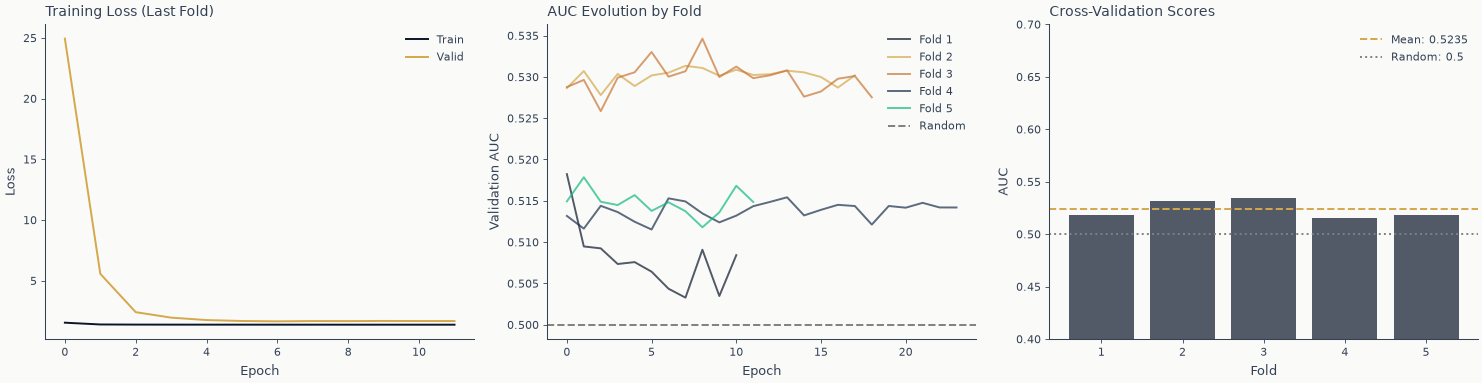

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training curves (last fold)
ax1 = axes[0]
ax1.plot(fold_histories[-1]["train_loss"], label="Train", color=COLORS["blue"])
ax1.plot(fold_histories[-1]["val_loss"], label="Valid", color=COLORS["amber"])
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training Loss (Last Fold)")
ax1.legend()

# AUC evolution
ax2 = axes[1]
for i, hist in enumerate(fold_histories):
    ax2.plot(hist["val_auc"], alpha=0.7, label=f"Fold {i + 1}")
ax2.axhline(0.5, color="gray", linestyle="--", label="Random")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation AUC")
ax2.set_title("AUC Evolution by Fold")
ax2.legend()

# Fold scores
ax3 = axes[2]
ax3.bar(range(1, len(fold_scores) + 1), fold_scores, color=COLORS["blue"], alpha=0.7)
ax3.axhline(
    np.mean(fold_scores),
    color=COLORS["amber"],
    linestyle="--",
    label=f"Mean: {np.mean(fold_scores):.4f}",
)
ax3.axhline(0.5, color="gray", linestyle=":", label="Random: 0.5")
ax3.set_xlabel("Fold")
ax3.set_ylabel("AUC")
ax3.set_title("Cross-Validation Scores")
ax3.legend()
ax3.set_ylim(0.4, 0.7)

fig.tight_layout()
fig.show()

## 9. Feature Importance via Reconstruction Error

The autoencoder learns which features are important for reconstruction.
Features with high reconstruction error may be:
1. Noisy (hard to compress)
2. Unique (not captured by other features)
3. Important predictors (the model focuses on them)


Top 10 features hardest to reconstruct:
  1. Feature 6: MSE = 0.0033
  2. Feature 10: MSE = 0.0026
  3. Feature 3: MSE = 0.0025
  4. Feature 9: MSE = 0.0025
  5. Feature 12: MSE = 0.0025
  6. Feature 14: MSE = 0.0024
  7. Feature 8: MSE = 0.0020
  8. Feature 11: MSE = 0.0015
  9. Feature 0: MSE = 0.0008
  10. Feature 4: MSE = 0.0007


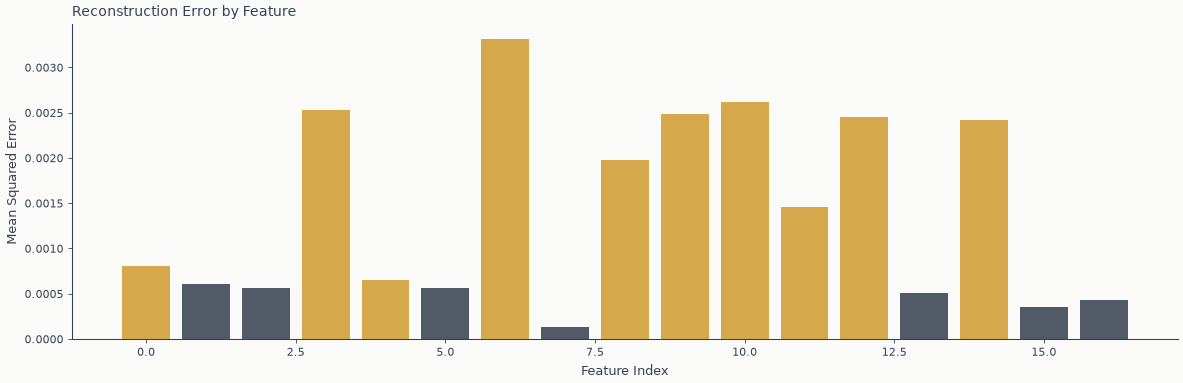

In [24]:
# Analyze reconstruction quality
model = fold_models[-1]
model.eval()

with torch.no_grad():
    # Get a batch for analysis
    sample_idx = rng.choice(len(X), min(10000, len(X)), replace=False)
    X_sample = X[sample_idx].to(device)

    decoded, _, _ = model(X_sample)
    decoded = decoded.cpu().numpy()
    original = X_sample.cpu().numpy()

# Per-feature reconstruction error
recon_errors = np.mean((original - decoded) ** 2, axis=0)

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(recon_errors)), recon_errors, color=COLORS["blue"], alpha=0.7)
ax.set_xlabel("Feature Index")
ax.set_ylabel("Mean Squared Error")
ax.set_title("Reconstruction Error by Feature")

# Highlight top 10 hardest to reconstruct
top_10 = np.argsort(recon_errors)[-10:]
for idx in top_10:
    ax.bar(idx, recon_errors[idx], color=COLORS["amber"])

fig.tight_layout()
fig.show()

print("\nTop 10 features hardest to reconstruct:")
for i, idx in enumerate(top_10[::-1]):
    print(f"  {i + 1}. Feature {idx}: MSE = {recon_errors[idx]:.4f}")

**Interpretation**: Features with high reconstruction error tend to be those with
the most idiosyncratic variation — z-scores and volume ratios are typically harder to
compress than smooth momentum signals. The autoencoder effectively denoises these
features by routing them through the bottleneck, which is why the reconstruction
objective serves as implicit feature selection: the model allocates bottleneck
capacity to the most informative features.

## Key Takeaways

1. **Multi-task learning as regularization**: The reconstruction loss forces the encoder
   bottleneck to capture structure that also has to support the reconstruction target,
   rather than tuning the bottleneck only to the supervised target. This notebook does
   not run an MLP-only ablation; the comparison against a no-reconstruction baseline
   lives in the `us_firm_characteristics` case study.
2. **Skip connections preserve raw signal**: Concatenating original features with the
   bottleneck representation gives the main prediction head access to both denoised
   and raw information.
3. **Purged cross-validation prevents leakage**: The 41-day gap between train and test
   windows (one day past the longest forecast horizon of 40 days) prevents the
   realisation windows of training labels from overlapping the test window — without
   this, a 40-day-horizon training label whose timestamp sits within 40 days of the
   test start would carry test-period return information into training.
4. **Swish activation**: The smooth, non-monotonic gating $x \cdot \sigma(x)$ has a
   non-zero gradient for negative inputs, which avoids the zero-gradient region that
   ReLU exhibits for $x<0$. This notebook follows the Jane Street 2020-21 reference
   implementation's choice; no ReLU ablation is run here.

**Next**: For supervised autoencoders applied to firm characteristics with full
walk-forward CV and Optuna HPO, see [`08_latent_factors`](../case_studies/us_firm_characteristics/08_latent_factors.ipynb).
For the cross-dataset comparison of all latent factor models, see
[`09_case_study_insights`](09_case_study_insights.ipynb).